# MY_71_R: second- and third-best ports when each port was best
Sessions **216–231 inclusive**. One figure with two heatmaps: second-best and third-best ports, conditional on the best port (rows).

Ranks are determined by **available reward magnitude on each completed trial**, not by how often the mouse chose a port. Counts pool trials across sessions (longer periods contribute more). Percentages use the number of eligible trials where the named port was best. Only the available choice ports are ranked; unavailable ports are not treated as zero-value options. Port-finding trials are excluded, matching the repository importer. Trials with missing/invalid magnitudes or ties are excluded and reported rather than arbitrarily breaking ties.

In [1]:
from pathlib import Path
import json
import re
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/my71r-matplotlib")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

SUBJECT = "MY_71_R"
FIRST_SESSION, LAST_SESSION = 216, 231
PORTS = ["A1", "A2", "A3", "B1", "B3", "C1", "C2", "C3"]
SUBJECT_DIR = Path("/Volumes/behrens/meg/3x3_field_magnitude_bandit/rawdata/cohort-01/sub-03_id-MY_71_R")
REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src/behavior_import").is_dir())
OUTPUT_DIR = REPO_ROOT / "results/figures/MY_71_R_sessions_216-231_port_rankings"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## Load the selected sessions
Read trial JSON directly from the raw TSVs, using the same `variable / print` filter and field aliases as `src/behavior_import/extract_trials.py`. All recording files in each session are included; source file and row are retained for traceability. Missing sessions stop execution.

In [2]:
session_dirs = {}
for path in SUBJECT_DIR.glob("ses-*_date-*"):
    match = re.fullmatch(r"ses-(\d+)_date-(\d{8})", path.name)
    if match and FIRST_SESSION <= int(match[1]) <= LAST_SESSION:
        number = int(match[1])
        if number in session_dirs:
            raise ValueError(f"Duplicate session number: {number}")
        session_dirs[number] = path
missing = sorted(set(range(FIRST_SESSION, LAST_SESSION + 1)) - session_dirs.keys())
if missing:
    raise FileNotFoundError(f"Missing sessions {missing}. Check SUBJECT_DIR: {SUBJECT_DIR}")

records, file_counts = [], {}
for session, folder in sorted(session_dirs.items()):
    files = sorted(folder.rglob("*.tsv"))
    if not files:
        raise FileNotFoundError(f"No TSV files in {folder}")
    file_counts[session] = len(files)
    for file in files:
        raw = pd.read_csv(file, sep="\t")
        trials = raw.loc[raw["type"].eq("variable") & raw["subtype"].eq("print")].sort_values("time")
        for row_index, row in trials.iterrows():
            info = json.loads(row["content"])
            if "num_t_found" in info:
                continue
            mags = info.get("current_reward_magnitudes", info.get("curr_rew_mag"))
            record = dict(session=session, source_file=str(file), source_row=int(row_index) + 2,
                          trial=info.get("num_trials", info.get("num_t")),
                          best=None, second=None, third=None, exclusion="")
            if not isinstance(mags, dict) or len(mags) < 3:
                record["exclusion"] = "missing magnitudes / fewer than 3 ports"
            elif any(port not in PORTS for port in mags):
                raise ValueError(f"Unexpected choice ports in {file}: {mags}")
            elif any(not isinstance(v, (int, float)) or not np.isfinite(v) for v in mags.values()):
                record["exclusion"] = "invalid magnitudes"
            elif len(set(mags.values())) != len(mags):
                record["exclusion"] = "tied magnitudes"
            else:
                ranked = sorted(mags, key=mags.get, reverse=True)
                record.update(zip(["best", "second", "third"], ranked[:3]))
            records.append(record)
trials = pd.DataFrame(records)
if trials.empty:
    raise ValueError("No completed trials found.")
valid = trials.loc[trials["exclusion"].eq("")].copy()
coverage = trials.groupby("session").agg(total_trials=("session", "size"),
    eligible_trials=("exclusion", lambda x: x.eq("").sum()))
coverage = coverage.reindex(range(FIRST_SESSION, LAST_SESSION + 1), fill_value=0)
coverage["excluded_trials"] = coverage.total_trials - coverage.eligible_trials
coverage["files"] = pd.Series(file_counts)
display(coverage)
if (coverage.total_trials == 0).any():
    raise ValueError("At least one session has no completed trials; see coverage above.")
print(f"{len(valid):,} eligible trials out of {len(trials):,} completed trials.")
if (~trials.exclusion.eq("")).any():
    display(trials.loc[~trials.exclusion.eq(""), "exclusion"].value_counts().rename("excluded_trials"))


,total_trials,eligible_trials,excluded_trials,files
session,,,,
216,35,35,0,6
217,47,47,0,3
218,72,72,0,5
219,88,88,0,6
220,78,78,0,4
221,80,80,0,6
222,88,88,0,3
223,75,75,0,4
224,80,80,0,3


1,223 eligible trials out of 1,223 completed trials.


## Count the second- and third-best ports
Each heatmap row is normalized by the number of eligible trials where that row's port was best. Both panels share a 0–100% color scale; cells show percentages and trial counts. Gray cells are unavailable: the diagonal cannot occur, and A3 was never best. Zero-valued cells elsewhere are observed zero counts. These are descriptive trial frequencies, not independent samples or measures of choice preference.

In [3]:
counts = {}
for rank in ["second", "third"]:
    counts[rank] = pd.crosstab(valid["best"], valid[rank]).reindex(index=PORTS, columns=PORTS, fill_value=0)
    counts[rank].index.name = "best_port"
    counts[rank].columns.name = f"{rank}_best_port"
n_best = valid["best"].value_counts().reindex(PORTS, fill_value=0)
for rank, table in counts.items():
    assert table.sum(axis=1).equals(n_best.rename_axis("best_port")), f"Count mismatch: {rank}"
    assert np.diag(table.to_numpy()).sum() == 0
    print(f"{rank.capitalize()}-best port counts (rows = best port)")
    display(table)


Second-best port counts (rows = best port)


second_best_port,A1,A2,A3,B1,B3,C1,C2,C3
best_port,,,,,,,,
A1,0,0,0,0,38,91,0,26
A2,0,0,0,64,0,0,10,60
A3,0,0,0,0,0,0,0,0
B1,0,89,0,0,13,0,121,51
B3,6,0,0,64,0,75,49,0
C1,70,0,0,0,36,0,0,45
C2,0,51,0,97,16,0,0,0
C3,26,35,0,42,0,48,0,0


Third-best port counts (rows = best port)


third_best_port,A1,A2,A3,B1,B3,C1,C2,C3
best_port,,,,,,,,
A1,0,0,0,0,41,64,0,50
A2,0,0,0,70,0,0,35,29
A3,0,0,0,0,0,0,0,0
B1,0,112,0,0,60,0,62,40
B3,75,0,0,49,0,6,64,0
C1,81,0,0,0,23,0,0,47
C2,0,40,0,67,57,0,0,0
C3,48,42,0,35,0,26,0,0


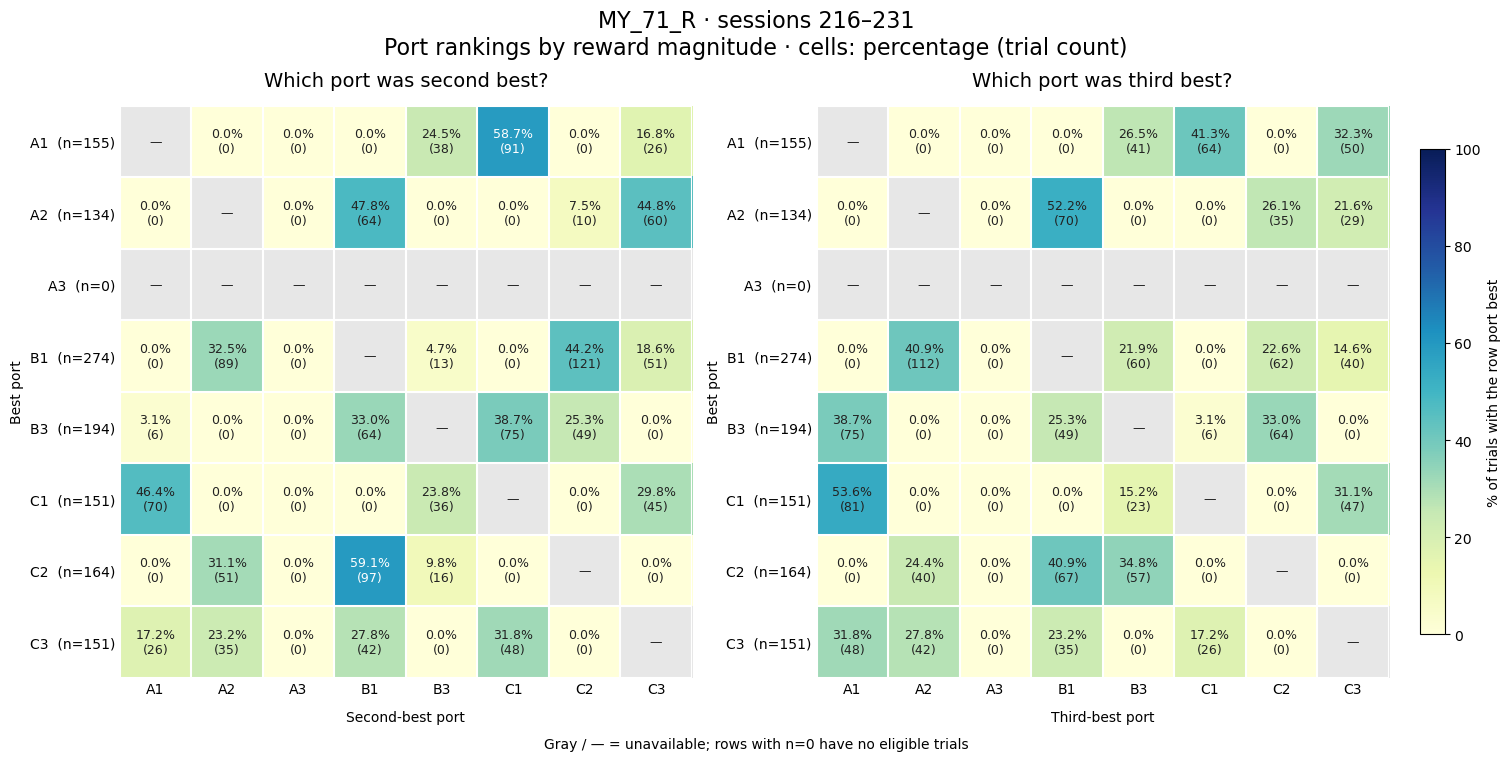

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7.5), layout="constrained")
cmap = plt.get_cmap("YlGnBu").copy()
cmap.set_bad("#e7e7e7")
for ax, rank in zip(axes, ["second", "third"]):
    table = counts[rank]
    percentages = table.div(n_best.replace(0, np.nan), axis=0) * 100
    values = percentages.to_numpy(dtype=float)
    np.fill_diagonal(values, np.nan)
    im = ax.imshow(np.ma.masked_invalid(values), cmap=cmap, vmin=0, vmax=100)
    ax.set_xticks(range(len(PORTS)), PORTS)
    ax.set_yticks(range(len(PORTS)), [f"{port}  (n={int(n_best[port])})" for port in PORTS])
    ax.set_xlabel(f"{rank.capitalize()}-best port", labelpad=10)
    ax.set_ylabel("Best port")
    ax.set_title(f"Which port was {rank} best?", pad=14, fontsize=14)
    ax.set_xticks(np.arange(-0.5, len(PORTS), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(PORTS), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.5)
    ax.tick_params(which="both", length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)
    for row in range(len(PORTS)):
        for col in range(len(PORTS)):
            value = values[row, col]
            label = "—" if np.isnan(value) else f"{value:.1f}%\n({table.iloc[row, col]})"
            ax.text(col, row, label, ha="center", va="center", fontsize=9,
                    color="white" if np.isfinite(value) and value >= 55 else "#222222")
fig.colorbar(im, ax=axes, shrink=0.75, pad=0.025, label="% of trials with the row port best")
fig.suptitle(f"{SUBJECT} · sessions {FIRST_SESSION}–{LAST_SESSION}\n"
             "Port rankings by reward magnitude · cells: percentage (trial count)", fontsize=16)
fig.supxlabel("Gray / — = unavailable; rows with n=0 have no eligible trials", fontsize=10)
fig.savefig(OUTPUT_DIR / "port_rank_heatmaps.png", dpi=200, bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "port_rank_heatmaps.pdf", bbox_inches="tight")
plt.show()
plt.close(fig)

In [5]:
trials.to_csv(OUTPUT_DIR / "trial_rankings.csv", index=False)
coverage.to_csv(OUTPUT_DIR / "session_coverage.csv")
for rank, table in counts.items():
    table.to_csv(OUTPUT_DIR / f"{rank}_best_counts.csv")
print(f"Saved the combined heatmap figure (PNG and PDF), count tables, coverage, and trial rankings to:\n{OUTPUT_DIR}")

Saved the combined heatmap figure (PNG and PDF), count tables, coverage, and trial rankings to:
/Users/megyoung/magnitude-bandit-analysis/results/figures/MY_71_R_sessions_216-231_port_rankings
